<a href="https://colab.research.google.com/github/donutellah/philippine-stocks-network/blob/main/PSEi_Graph_Analysis_MAT305.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup & Dependencies

In [3]:
!pip install beautifulsoup4 requests pandas numpy matplotlib seaborn networkx scipy

# 2. Data Loading (PSE Edge scraper)

In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import re
import time
import json
import warnings
from community import community_louvain
import scipy.linalg as la
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [5]:
def search_pse_company_id(stock_symbol):
    """Search PSE Edge and extract company IDs"""
    url = "https://edge.pse.com.ph/companyDirectory/search.ax"
    params = {'keyword': stock_symbol}
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Referer': 'https://edge.pse.com.ph/'
    }

    try:
        response = requests.post(url, headers=headers, data=params, timeout=15)
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            table = soup.find('table', class_='list')
            if table:
                rows = table.find_all('tr')
                # Debug: Check if rows are found
                if not rows: print(f"Debug: No rows found in table for {stock_symbol}")
                for row in rows:
                    cells = row.find_all('td')
                    # Debug: Check cell length
                    if len(cells) < 2: continue # Skip rows without enough cells
                    symbol_cell = cells[1]
                    symbol_link = symbol_cell.find('a')
                    if symbol_link:
                        symbol_text = symbol_link.get_text(strip=True)
                        # Debug: Check if symbol matches
                        print(f"Debug: Found symbol link text '{symbol_text}' for {stock_symbol}")
                        if symbol_text == stock_symbol:
                            onclick = symbol_link.get('onclick', '')
                            # Debug: Check onclick attribute
                            print(f"Debug: Onclick attribute for {stock_symbol}: '{onclick}'")
                            match = re.search(r"cmDetail\('(\d+)','(\d+)'\)", onclick)
                            if match:
                                return {
                                    'symbol': stock_symbol,
                                    'company_name': cells[0].get_text(strip=True),
                                    'company_id': match.group(1),
                                    'security_id': match.group(2)
                                }
                            else: print(f"Debug: Onclick regex match failed for {stock_symbol} with onclick: '{onclick}'")
                    else: print(f"Debug: No symbol link found in second cell for {stock_symbol}")
            else: print(f"Debug: Table with class 'list' not found for {stock_symbol}")
        else: print(f"Debug: Response status code {response.status_code} for {stock_symbol}")
    except Exception as e:
        print(f"Error searching for {stock_symbol}: {e}")
    return None

def get_pse_historical_data(company_id, security_id, start_date='01-01-2023', end_date='12-31-2025'):
    """Download historical stock data from PSE Edge"""
    url = 'https://edge.pse.com.ph/common/DisclosureCht.ax'
    payload = {
        'cmpy_id': company_id,
        'security_id': security_id,
        'startDate': start_date,
        'endDate': end_date
    }
    headers = {
        'Content-Type': 'application/json',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Referer': 'https://edge.pse.com.ph/',
        'X-Requested-With': 'XMLHttpRequest'
    }

    try:
        response = requests.post(url, json=payload, headers=headers, timeout=15)
        if response.status_code == 200:
            data = response.json()
            return data.get('chartData', [])
    except Exception as e:
        print(f"Error downloading historical data for company {company_id}, security {security_id}: {e}")
    return None

def convert_to_dataframe(chart_data):
    """Convert PSE data to pandas DataFrame"""
    if not chart_data:
        return None
    df = pd.DataFrame(chart_data)
    df['Date'] = pd.to_datetime(df['CHART_DATE'])
    df = df.rename(columns={'CLOSE': 'Close'})
    df = df[['Date', 'Close']]
    df = df.set_index('Date')
    df = df.sort_index()
    df = df[~df.index.duplicated(keep='first')]
    return df

print("Functions defined successfully")

Functions defined successfully


In [6]:
print("="*70)
print("DOWNLOADING PSEi 30 STOCKS - COMPLETE DATASET")
print("="*70)
print()

# Complete list of 30 PSEi stocks tickers
psei_30_stocks = [
    'AC', 'AEV', 'AGI', 'ALI', 'BDO', 'BPI', 'CBC', 'DMC', 'GLO', 'ICT',
    'JFC', 'JGS', 'LOTO', 'MBT', 'MER', 'SCC', 'SMC', 'SM', 'SMPH', 'ACEN',
    'LTG', 'TEL', 'URC', 'PGOLD', 'EMI', 'GTCAP', 'CNPF', 'AREIT', 'CNVRG', 'MONDE'
]

print(f"Downloading {len(psei_30_stocks)} stocks...")
print(f"Date range: January 1, 2023 - December 31, 2025")
print()

all_data = {}
company_info = {}

for stock in psei_30_stocks:
    print(f"Processing {stock}...", end=' ')

    # Search for company
    info = search_pse_company_id(stock)

    if info:
        company_info[stock] = info

        # Download historical data
        chart_data = get_pse_historical_data(info['company_id'], info['security_id'])

        if chart_data:
            df = convert_to_dataframe(chart_data)
            if df is not None and len(df) > 0:
                all_data[stock] = df
                print(f"✓ {len(df)} days")
            else:
                print(f"✗ No data")
        else:
            print(f"✗ Download failed")
    else:
        print(f"✗ Not found")

    time.sleep(2)  # Increased sleep to 2 seconds

print()
print("="*70)
print(f"DOWNLOAD COMPLETE: {len(all_data)}/{len(psei_30_stocks)} stocks")
print("="*70)

DOWNLOADING PSEi 30 STOCKS - COMPLETE DATASET

Date range: January 1, 2023 - December 31, 2025

Processing AC... Debug: Found symbol link text 'ABA' for AC
Debug: Found symbol link text 'AC' for AC
Debug: Onclick attribute for AC: 'cmDetail('57','180');return false;'
✓ 730 days
Processing AEV... Debug: Found symbol link text 'AEV' for AEV
Debug: Onclick attribute for AEV: 'cmDetail('16','183');return false;'
✓ 730 days
Processing AGI... Debug: Found symbol link text 'AGI' for AGI
Debug: Onclick attribute for AGI: 'cmDetail('212','179');return false;'
✓ 730 days
Processing ALI... Debug: Found symbol link text 'ALI' for ALI
Debug: Onclick attribute for ALI: 'cmDetail('180','293');return false;'
✓ 730 days
Processing BDO... Debug: Found symbol link text 'BDO' for BDO
Debug: Onclick attribute for BDO: 'cmDetail('260','468');return false;'
✓ 730 days
Processing BPI... Debug: Found symbol link text 'BPI' for BPI
Debug: Onclick attribute for BPI: 'cmDetail('234','101');return false;'
✓ 730 da

In [7]:
closing_prices = pd.DataFrame({stock: data['Close'] for stock, data in all_data.items()})

# Display data preview
print("Data Preview:")
print(closing_prices.head(10))
print()
print("Data Info:")
print(f"  Shape: {closing_prices.shape}")
print(f"  Missing values: {closing_prices.isnull().sum().sum()}")
print(f"  Memory usage: {closing_prices.memory_usage(deep=True).sum() / 1024:.2f} KB")

Data Preview:
               AC    AEV    AGI    ALI    BDO    BPI    CBC    DMC     GLO  \
Date                                                                         
2023-01-03  687.5  57.70  11.96  30.40  107.9   98.0  27.50  11.64  2220.0   
2023-01-04  687.0  58.90  11.96  31.25  111.5   98.3  27.45  11.80  2218.0   
2023-01-05  690.5  59.95  11.52  31.25  114.0   99.8  27.45  11.80  2164.0   
2023-01-06  684.0  58.70  11.40  30.25  111.0  100.6  27.45  11.72  2126.0   
2023-01-09  712.0  60.00  11.80  30.70  112.4  106.0  27.50  11.80  2132.0   
2023-01-10  703.0  59.00  11.80  30.00  110.9  104.5  27.30  11.70  2114.0   
2023-01-11  707.5  58.70  11.92  30.00  109.9  101.3  27.20  11.80  2060.0   
2023-01-12  732.0  59.50  11.96  31.00  114.0  103.1  27.45  12.18  2060.0   
2023-01-13  739.0  59.70  12.10  31.00  119.0  110.0  27.60  12.22  2098.0   
2023-01-16  768.0  59.05  12.52  31.60  125.5  112.4  27.70  12.60  2102.0   

              ICT  ...   LTG     TEL    URC  PGOL

In [8]:
import pandas as pd

print("="*70)
print("HANDLING MISSING DATA")
print("="*70)
print()

# Ensure closing_prices is defined
if 'all_data' not in globals() or not all_data:
    print("Error: 'all_data' is not defined or is empty. Please ensure cell 'rePX5kwwyj5P' is executed first to download the stock data.")
    # To prevent further errors in this cell, initialize closing_prices as empty and exit.
    closing_prices = pd.DataFrame()
else:
    closing_prices = pd.DataFrame({stock: data['Close'] for stock, data in all_data.items()})

# Check which stocks have missing data
if not closing_prices.empty:
    print("Missing values per stock:")
    missing_by_stock = closing_prices.isnull().sum()
    missing_by_stock = missing_by_stock[missing_by_stock > 0].sort_values(ascending=False)

    for stock, count in missing_by_stock.items():
        percentage = (count / len(closing_prices)) * 100
        print(f"  {stock:8s}: {count:3d} missing ({percentage:5.2f}%)")

    print()

    # Forward fill missing values (use last known price)
    # This is standard practice for stock market data
    closing_prices_filled = closing_prices.fillna(method='ffill')

    # If there are any remaining NaN at the beginning, backfill
    closing_prices_filled = closing_prices_filled.fillna(method='bfill')

    # Verify no more missing values
    remaining_missing = closing_prices_filled.isnull().sum().sum()

    print(f"After filling:")
    print(f"  Missing values: {remaining_missing}")
    print()

    if remaining_missing == 0:
        print("✓ All missing values handled successfully")

        # Save cleaned dataset
        closing_prices_filled.to_csv('psei_30_stocks_complete_cleaned.csv')
        print("✓ Saved cleaned dataset: psei_30_stocks_complete_cleaned.csv")
    else:
        print("⚠ Warning: Some missing values remain")

    # Use the filled dataset going forward
    data = closing_prices_filled
    print()
    print(f"Final dataset: {data.shape[0]} days × {data.shape[1]} stocks")
else:
    print("No stock data available to process missing values.")

HANDLING MISSING DATA

Missing values per stock:
  LOTO    :  78 missing (10.68%)
  CBC     :  43 missing ( 5.89%)

After filling:
  Missing values: 0

✓ All missing values handled successfully
✓ Saved cleaned dataset: psei_30_stocks_complete_cleaned.csv

Final dataset: 730 days × 30 stocks


# 3. Log Returns Computation

## Data Preprocessing: Calculate Logarithmic Returns

In [9]:
import numpy as np
import pandas as pd

# 1. Verify 'data' exists and calculate log returns
if 'data' in globals():
    # r(t) = ln(P(t) / P(t-1))
    returns_df = np.log(data / data.shift(1))

    # 2. Remove the first row containing NaN
    returns_df = returns_df.dropna()

    # 3. Print preview and descriptive statistics
    print('Logarithmic Returns Preview (First 5 rows):')
    print(returns_df.head())

    print('\nSummary Statistics (Mean and Std Dev):')
    summary_stats = pd.DataFrame({
        'Mean': returns_df.mean(),
        'Std Dev': returns_df.std()
    })
    print(summary_stats)
else:
    print('Error: "data" DataFrame not found in the environment.')

Logarithmic Returns Preview (First 5 rows):
                  AC       AEV       AGI       ALI       BDO       BPI  \
Date                                                                     
2023-01-04 -0.000728  0.020584  0.000000  0.027577  0.032820  0.003057   
2023-01-05  0.005082  0.017670 -0.037483  0.000000  0.022174  0.015144   
2023-01-06 -0.009458 -0.021071 -0.010471 -0.032523 -0.026668  0.007984   
2023-01-09  0.040120  0.021905  0.034486  0.014766  0.012534  0.052287   
2023-01-10 -0.012721 -0.016807  0.000000 -0.023065 -0.013435 -0.014252   

                 CBC       DMC       GLO       ICT  ...       LTG       TEL  \
Date                                                ...                       
2023-01-04 -0.001820  0.013652 -0.000901 -0.002528  ...  0.026555  0.066382   
2023-01-05  0.000000  0.000000 -0.024648  0.006058  ...  0.003140 -0.016713   
2023-01-06  0.000000 -0.006803 -0.017716 -0.013681  ... -0.005238 -0.027770   
2023-01-09  0.001820  0.006803  0.002818  

# 4. Pearson Correlation & Distance Matrix

## Structural Graph Construction: Mantegna Transformation

In [10]:
import numpy as np
import pandas as pd

# 1. Calculate the Pearson correlation matrix (rho)
correlation_matrix = returns_df.corr()

# 2. Transform into a distance matrix: d = sqrt(2 * (1 - rho))
distance_matrix = np.sqrt(2 * (1 - correlation_matrix))

# Display a preview of the distance matrix
print('Distance Matrix Preview (First 5x5):')
display(distance_matrix.iloc[:5, :5])

Distance Matrix Preview (First 5x5):


,AC,AEV,AGI,ALI,BDO
AC,0.000000,1.212509,1.311929,1.128377,1.214259
AEV,1.212509,0.000000,1.332556,1.216078,1.270252
AGI,1.311929,1.332556,0.000000,1.236392,1.306057
ALI,1.128377,1.216078,1.236392,0.000000,1.223222
BDO,1.214259,1.270252,1.306057,1.223222,0.000000


## Appendix B — Full Pairwise Distance Matrix

In [11]:
import pandas as pd
import numpy as np

# Set display options to show the full matrix
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("The complete 30 x 30 matrix of d_ij values after the Mantegna transformation\n")

# Display the distance matrix
display(distance_matrix)

# Reset display options to default after showing the matrix
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

The complete 30 x 30 matrix of d_ij values after the Mantegna transformation



,AC,AEV,AGI,ALI,BDO,BPI,CBC,DMC,GLO,ICT,JFC,JGS,LOTO,MBT,MER,SCC,SMC,SM,SMPH,ACEN,LTG,TEL,URC,PGOLD,EMI,GTCAP,CNPF,AREIT,CNVRG,MONDE
AC,0.000000,1.212509,1.311929,1.128377,1.214259,1.181677,1.373619,1.290576,1.247161,1.222876,1.193356,1.151932,1.434720,1.172010,1.245199,1.332982,1.385349,1.103565,1.075443,1.282224,1.318502,1.245040,1.174628,1.235402,1.389711,1.215423,1.378145,1.307978,1.318038,1.247241
AEV,1.212509,0.000000,1.332556,1.216078,1.270252,1.278772,1.419357,1.326516,1.363417,1.326765,1.180854,1.152859,1.403295,1.225489,1.332633,1.319794,1.294024,1.266897,1.237985,1.287386,1.345129,1.370684,1.232335,1.280919,1.366846,1.283793,1.391877,1.371109,1.329355,1.314892
AGI,1.311929,1.332556,0.000000,1.236392,1.306057,1.292028,1.559367,1.259996,1.348062,1.389038,1.284759,1.299963,1.391646,1.343705,1.284087,1.309559,1.191631,1.284384,1.305740,1.260733,1.267625,1.342605,1.277959,1.251579,1.319376,1.236964,1.270696,1.438824,1.298296,1.279557
ALI,1.128377,1.216078,1.236392,0.000000,1.223222,1.196167,1.421884,1.259659,1.269513,1.262817,1.162943,1.127704,1.410403,1.234900,1.228076,1.273487,1.324974,1.196000,1.021650,1.199804,1.310343,1.270825,1.217414,1.247998,1.388440,1.171606,1.319972,1.368374,1.232846,1.256284
BDO,1.214259,1.270252,1.306057,1.223222,0.000000,1.166441,1.372366,1.312482,1.293082,1.240197,1.172266,1.293546,1.410717,1.160316,1.284552,1.313155,1.386053,1.232418,1.198733,1.281982,1.373495,1.284737,1.207008,1.291878,1.421391,1.233123,1.335925,1.359733,1.322230,1.255885
BPI,1.181677,1.278772,1.292028,1.196167,1.166441,0.000000,1.423463,1.343284,1.297814,1.245163,1.207887,1.236282,1.399184,1.187135,1.253920,1.330270,1.322780,1.223069,1.188424,1.269742,1.320691,1.249709,1.240380,1.284241,1.411062,1.225961,1.319629,1.390690,1.273888,1.253187
CBC,1.373619,1.419357,1.559367,1.421884,1.372366,1.423463,0.000000,1.408992,1.414594,1.386285,1.433384,1.381425,1.392994,1.326178,1.406952,1.430579,1.614233,1.360799,1.389827,1.415260,1.449563,1.351361,1.374113,1.489570,1.565600,1.400015,1.432927,1.304142,1.441021,1.373797
DMC,1.290576,1.326516,1.259996,1.259659,1.312482,1.343284,1.408992,0.000000,1.203497,1.311684,1.274706,1.302852,1.418382,1.333472,1.311260,1.125682,1.424769,1.275698,1.298556,1.252132,1.291397,1.265359,1.305017,1.270033,1.377696,1.283175,1.368812,1.343745,1.269442,1.278579
GLO,1.247161,1.363417,1.348062,1.269513,1.293082,1.297814,1.414594,1.203497,0.000000,1.283584,1.268174,1.283906,1.412140,1.276707,1.272951,1.316334,1.400595,1.279878,1.227681,1.227240,1.292519,1.150672,1.280268,1.268302,1.378707,1.311884,1.391195,1.319880,1.281783,1.283444
ICT,1.222876,1.326765,1.389038,1.262817,1.240197,1.245163,1.386285,1.311684,1.283584,0.000000,1.246972,1.229792,1.462381,1.255920,1.256285,1.346610,1.409340,1.281418,1.262531,1.322713,1.322436,1.234820,1.287020,1.299476,1.349496,1.332712,1.343235,1.375768,1.300746,1.275115


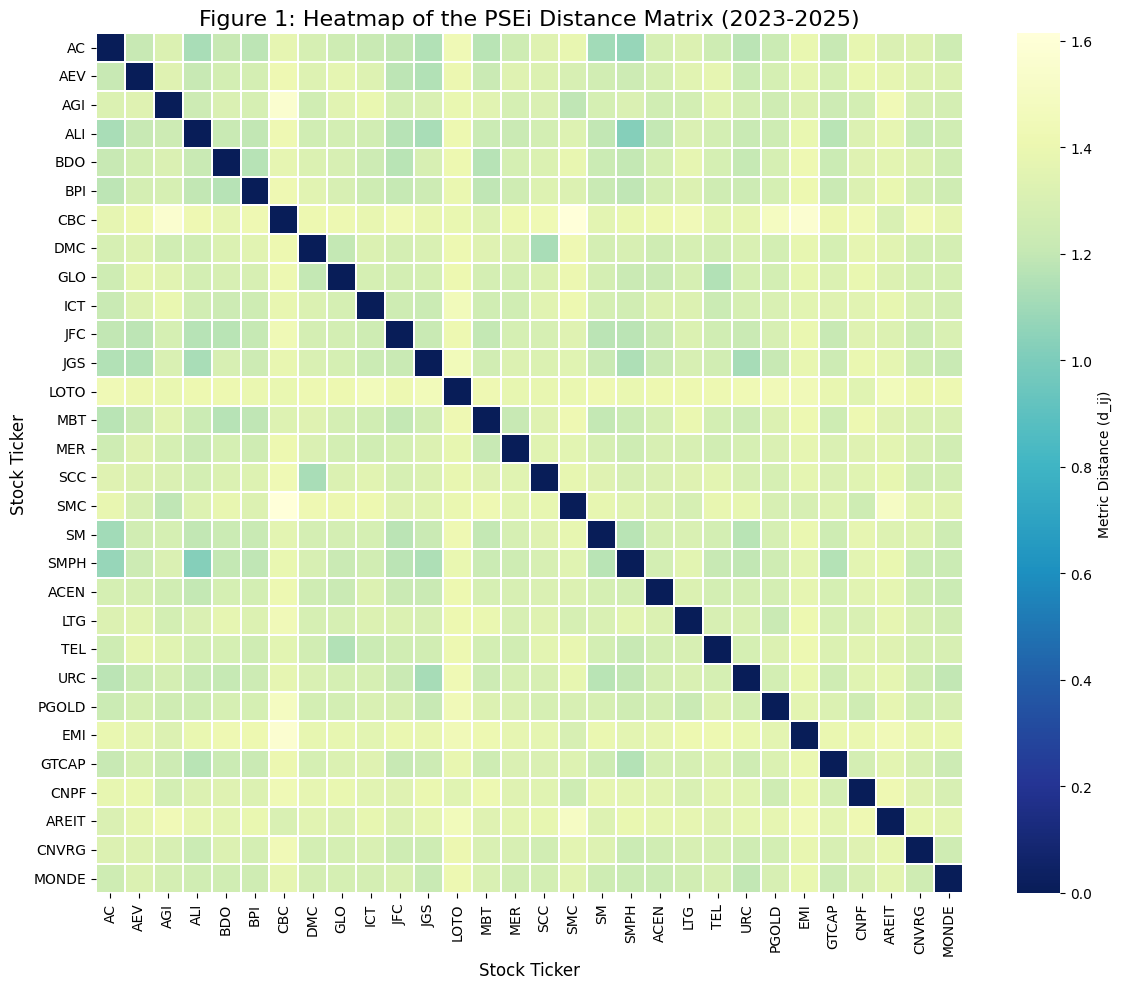

Heatmap generated and saved as PSEi_Distance_Heatmap.png


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Flag to indicate if we can proceed with plotting
can_proceed = False

# Ensure returns_df is available to calculate distance_matrix
if 'returns_df' in globals():
    # Calculate the Pearson correlation matrix (rho)
    correlation_matrix = returns_df.corr()

    # Transform into a distance matrix: d = sqrt(2 * (1 - rho))
    distance_matrix = np.sqrt(2 * (1 - correlation_matrix))
    can_proceed = True
else:
    print("Error: 'returns_df' is not defined. Please ensure the 'Data Preprocessing: Calculate Logarithmic Returns' step has been executed.")

# Only proceed with plotting if distance_matrix was successfully created
if can_proceed:
    # Set up the plotting environment
    plt.figure(figsize=(12, 10))

    # Generate the heatmap using the YlGnBu_r colormap
    # Darker regions indicate lower distance (higher correlation)
    sns.heatmap(distance_matrix, cmap='YlGnBu_r', annot=False, fmt='.2f',
                linewidths=0.1, cbar_kws={'label': 'Metric Distance (d_ij)'})

    plt.title('Figure 1: Heatmap of the PSEi Distance Matrix (2023-2025)', fontsize=16)
    plt.xlabel('Stock Ticker', fontsize=12)
    plt.ylabel('Stock Ticker', fontsize=12)

    # Adjust layout and save the visualization
    plt.tight_layout()
    plt.savefig('PSEi_Distance_Heatmap.png', dpi=300)
    plt.show()

    print("Heatmap generated and saved as PSEi_Distance_Heatmap.png")
else:
    print("Heatmap could not be generated due to missing 'returns_df'. Please run cell fa381757 first.")

# 5. Graph Construction & Threshold Filtering

## Structural Graph Construction

In [12]:
import numpy as np
import pandas as pd
import networkx as nx

# 1. Create an unweighted adjacency matrix with threshold d <= 1.2
# We convert to integer (0 or 1) and ensure diagonal is 0 to avoid self-loops
threshold = 1.2
adj_matrix = (distance_matrix <= threshold).astype(int)
np.fill_diagonal(adj_matrix.values, 0)

# 2. Initialize NetworkX Graph from the adjacency matrix
structural_graph = nx.from_pandas_adjacency(adj_matrix)

# 3. Print graph properties to verify structure
print('Structural Graph Construction Complete')
print(f'Threshold used: {threshold}')
print(f'Number of nodes: {structural_graph.number_of_nodes()}')
print(f'Number of edges: {structural_graph.number_of_edges()}')

# Display a preview of the adjacency matrix
print('\nAdjacency Matrix Preview (First 5x5):')
display(adj_matrix.iloc[:5, :5])

Structural Graph Construction Complete
Threshold used: 1.2
Number of nodes: 30
Number of edges: 35

Adjacency Matrix Preview (First 5x5):


,AC,AEV,AGI,ALI,BDO
AC,0,0,0,1,0
AEV,0,0,0,0,0
AGI,0,0,0,0,0
ALI,1,0,0,0,0
BDO,0,0,0,0,0


## Data Preprocessing Pipeline

### Subtask:
Calculate logarithmic returns for the cleaned PSEi 30 stock prices to prepare for correlation analysis.


In [13]:
import numpy as np
import pandas as pd
import networkx as nx

# 1. Create an unweighted adjacency matrix with threshold d <= 1.2
# We convert to integer (0 or 1) and ensure diagonal is 0 to avoid self-loops
threshold = 1.2
adj_matrix = (distance_matrix <= threshold).astype(int)
np.fill_diagonal(adj_matrix.values, 0)

# 2. Initialize NetworkX Graph from the adjacency matrix
structural_graph = nx.from_pandas_adjacency(adj_matrix)

# 3. Print graph properties to verify structure
print('Structural Graph Construction Complete')
print(f'Threshold used: {threshold}')
print(f'Number of nodes: {structural_graph.number_of_nodes()}')
print(f'Number of edges: {structural_graph.number_of_edges()}')

# Display a preview of the adjacency matrix
print('\nAdjacency Matrix Preview (First 5x5):')
display(adj_matrix.iloc[:5, :5])

Structural Graph Construction Complete
Threshold used: 1.2
Number of nodes: 30
Number of edges: 35

Adjacency Matrix Preview (First 5x5):


,AC,AEV,AGI,ALI,BDO
AC,0,0,0,1,0
AEV,0,0,0,0,0
AGI,0,0,0,0,0
ALI,1,0,0,0,0
BDO,0,0,0,0,0


# 6. MST & KNN Graph Building

## Appendix C — Full Centrality Table (All 30 Constituents)

In [14]:
import pandas as pd
import networkx as nx
from community import community_louvain

print("Generating full centrality table for all 30 constituents...\n")

# 1. Calculate Centrality Measures
degree_cent = nx.degree_centrality(structural_graph)
betweenness_cent = nx.betweenness_centrality(structural_graph)

# Ensure max_iter is high enough for convergence, especially for sparse graphs
eigenvector_cent = nx.eigenvector_centrality(structural_graph, max_iter=1000, weight=None)

# 2. Perform Community Detection using Louvain algorithm
# Create a temporary graph with weights if the original structural_graph is unweighted
# and Louvain benefits from weights.
# For an unweighted graph, community_louvain.best_partition directly works.
partition = community_louvain.best_partition(structural_graph)

# 3. Combine into DataFrame
centrality_table_full = pd.DataFrame({
    'Ticker': list(structural_graph.nodes()),
    'Degree': [degree_cent[node] for node in structural_graph.nodes()],
    'Betweenness': [betweenness_cent[node] for node in structural_graph.nodes()],
    'Eigenvector': [eigenvector_cent[node] for node in structural_graph.nodes()],
    'Louvain Community': [partition[node] for node in structural_graph.nodes()]
})

# Sort by Betweenness Centrality in descending order for better analysis of hubs
centrality_table_full = centrality_table_full.sort_values(by='Betweenness', ascending=False).reset_index(drop=True)

# Set the index to start from 1
centrality_table_full.index = centrality_table_full.index + 1

# Display the full table
print("Full Centrality Table (All 30 Constituents):\n")
display(centrality_table_full)

print("\nThis table provides the full ranking and community assignments, justifying claims about high-centrality nodes clustering.")

Generating full centrality table for all 30 constituents...

Full Centrality Table (All 30 Constituents):



,Ticker,Degree,Betweenness,Eigenvector,Louvain Community
1,ALI,0.275862,0.042124,3.789996e-01,0
2,SMPH,0.310345,0.037896,4.356495e-01,0
3,URC,0.172414,0.030172,2.510472e-01,12
4,AC,0.275862,0.027756,4.078517e-01,0
5,JFC,0.206897,0.017623,3.140022e-01,0
6,JGS,0.172414,0.015423,2.700026e-01,12
7,BPI,0.172414,0.006527,2.700613e-01,4
8,BDO,0.137931,0.004334,2.008161e-01,4
9,SM,0.172414,0.004105,3.066849e-01,0
10,MBT,0.103448,0.000616,1.507620e-01,4



This table provides the full ranking and community assignments, justifying claims about high-centrality nodes clustering.


Isolated Assets Identified: CBC, ICT, LOTO, MER, LTG, PGOLD, EMI, CNPF, AREIT, CNVRG


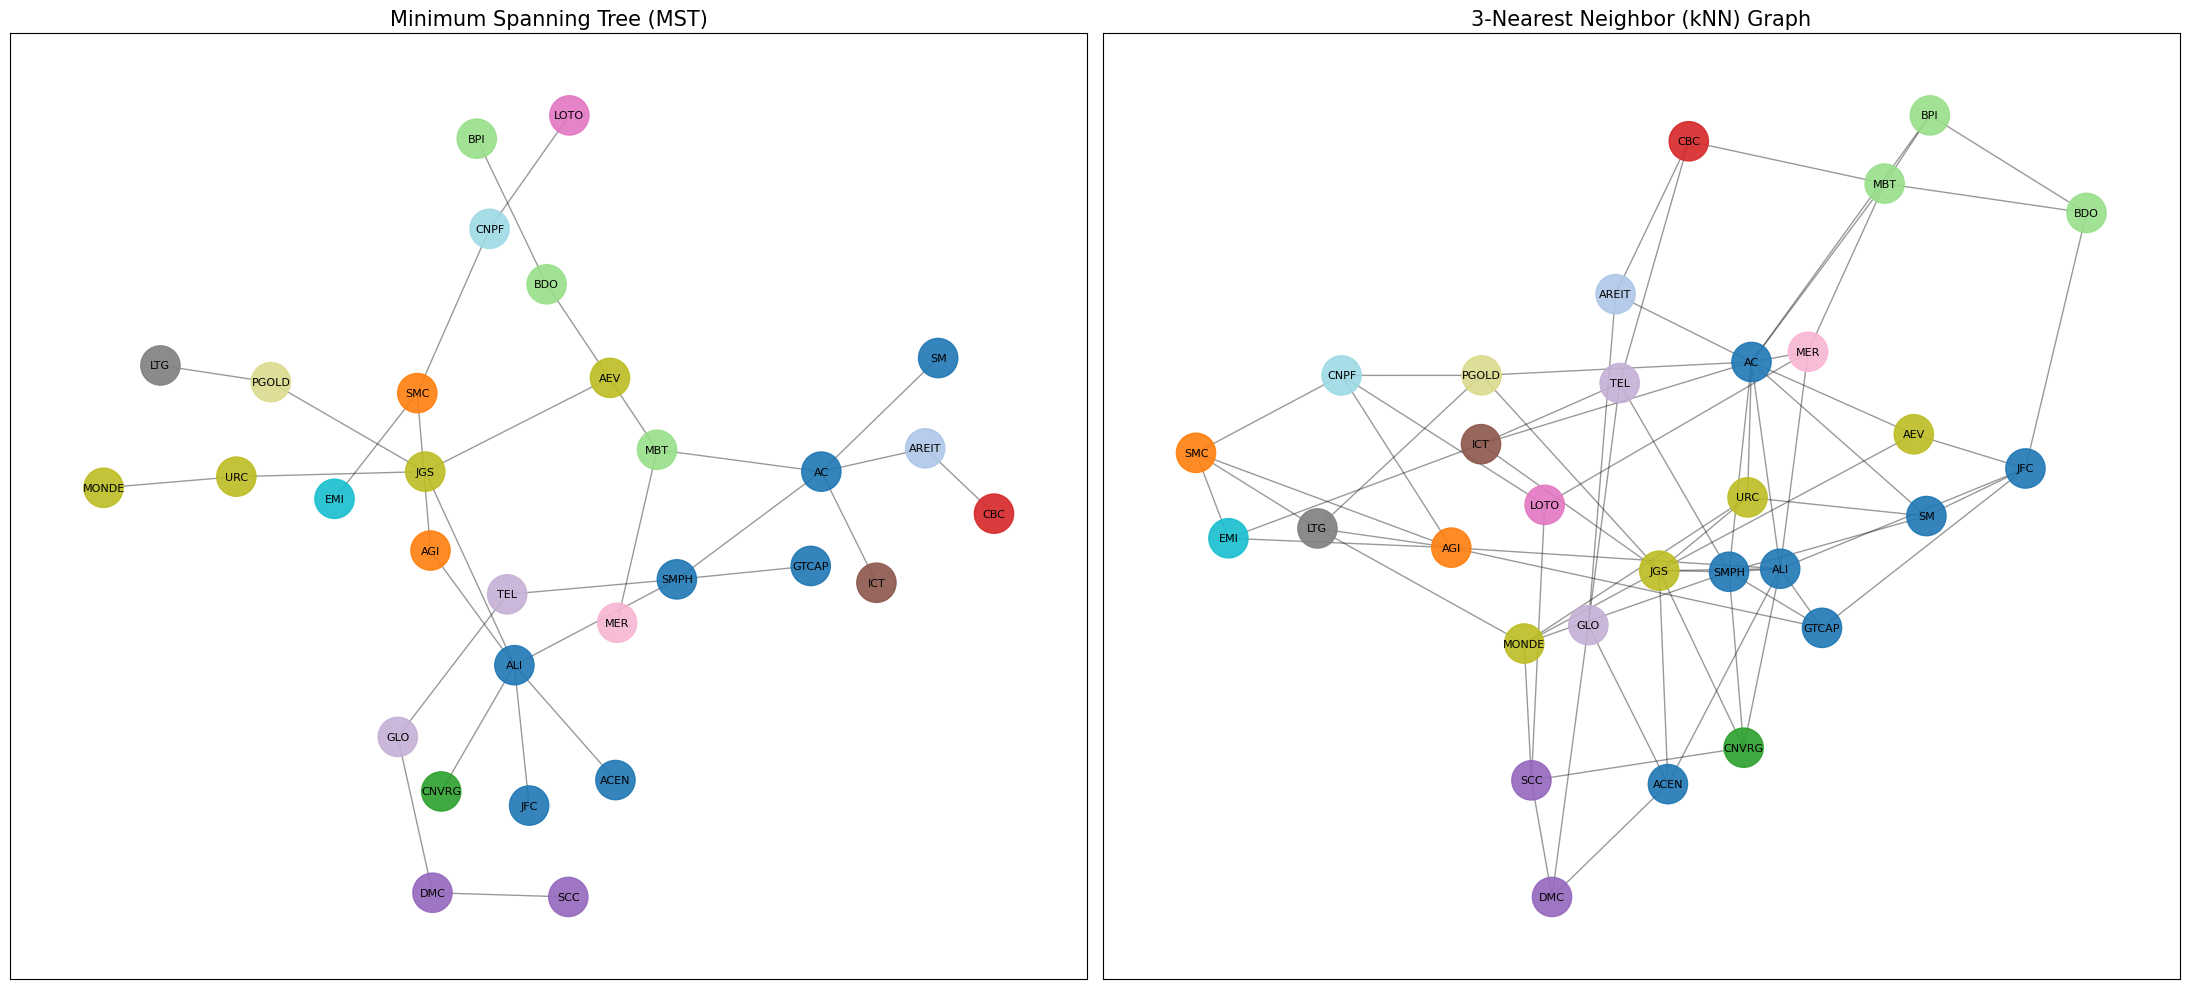

In [22]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# 1. Minimum Spanning Tree (MST)
complete_graph = nx.from_pandas_adjacency(distance_matrix)
mst_graph = nx.minimum_spanning_tree(complete_graph, weight='weight')

# 2. kNN Graph (k=3)
k = 3
knn_adj = np.zeros(distance_matrix.shape)
for i in range(len(distance_matrix)):
    # Get indices of k smallest distances (excluding self at 0)
    idx = np.argsort(distance_matrix.iloc[i, :])[1:k+1]
    knn_adj[i, idx] = 1
    knn_adj[idx, i] = 1
knn_graph = nx.from_numpy_array(knn_adj)
mapping = {i: col for i, col in enumerate(distance_matrix.columns)}
nx.relabel_nodes(knn_graph, mapping, copy=False)

# 3. Setup Layout and Coloring
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
pos_mst = nx.spring_layout(mst_graph, k=0.5, seed=42)
pos_knn = nx.spring_layout(knn_graph, k=0.5, seed=42)

# Get communities from previous partition
# Handle the 16 distinct communities using a diverse colormap
cmap = plt.get_cmap('tab20', 16)
node_colors = [partition[n] for n in structural_graph.nodes()]

# Visualize MST
nx.draw_networkx_nodes(mst_graph, pos_mst, node_size=800, node_color=node_colors, cmap=cmap, ax=ax1, alpha=0.9)
nx.draw_networkx_edges(mst_graph, pos_mst, alpha=0.4, ax=ax1)
nx.draw_networkx_labels(mst_graph, pos_mst, font_size=8, ax=ax1)
ax1.set_title("Minimum Spanning Tree (MST)", fontsize=15)

# Visualize kNN Graph
nx.draw_networkx_nodes(knn_graph, pos_knn, node_size=800, node_color=node_colors, cmap=cmap, ax=ax2, alpha=0.9)
nx.draw_networkx_edges(knn_graph, pos_knn, alpha=0.4, ax=ax2)
nx.draw_networkx_labels(knn_graph, pos_knn, font_size=8, ax=ax2)
ax2.set_title(f"{k}-Nearest Neighbor (kNN) Graph", fontsize=15)

# Identify Isolated Assets (Components with size 1 in original structural graph)
isolated = [node for node, degree in dict(structural_graph.degree()).items() if degree == 0]
print(f"Isolated Assets Identified: {', '.join(isolated) if isolated else 'None'}")

plt.tight_layout()
plt.savefig('PSEi_Topological_Maps.png', dpi=300)
plt.show()

# 7. Centrality Analysis

In [16]:
import scipy.linalg as la
import networkx as nx
import numpy as np
import pandas as pd

# 1. Compute Graph Laplacian and Algebraic Connectivity (λ₂)
def calculate_lambda_2(graph):
    # Handle cases for disconnected graphs or graphs with too few nodes
    if graph.number_of_nodes() <= 1:
        return 0.0 # Algebraic connectivity is 0 for trivial graphs

    # Check if the graph is connected. If not, the second eigenvalue is 0.
    # However, for the purpose of market resilience (fragmentation), we often want the *true* second smallest.
    # NetworkX's laplacian_matrix automatically handles disconnected components by yielding zero eigenvalues.
    L = nx.laplacian_matrix(graph).toarray()

    # Calculate eigenvalues in ascending order
    eigenvalues = la.eigvalsh(L)

    # If there are multiple zero eigenvalues (disconnected components), the algebraic connectivity (Fiedler value)
    # is the first non-zero eigenvalue. If all eigenvalues are zero (isolated nodes/no edges), return 0.
    # The second smallest eigenvalue is typically the algebraic connectivity.
    # If the graph has multiple connected components, its smallest eigenvalue is 0 with multiplicity equal to the number of components.
    # So, the second smallest is 0 if there's more than one component.
    # For a *connected* graph, lambda_2 > 0. For a disconnected graph, lambda_2 = 0 (unless we strictly mean the smallest non-zero).

    # For resilience, we are interested in the actual smallest non-zero eigenvalue.
    # However, standard definition of algebraic connectivity is the second smallest eigenvalue.
    # If the graph is disconnected, eigenvalues[1] will be 0.
    return eigenvalues[1] if len(eigenvalues) > 1 else 0.0

initial_lambda2 = calculate_lambda_2(structural_graph)
num_components_initial = nx.number_connected_components(structural_graph)

print(f"Initial Algebraic Connectivity (λ₂): {initial_lambda2:.4f}")
print(f"Initial Number of Connected Components: {num_components_initial}")

# 2. Identify Hubs via Betweenness Centrality
# We will use the already calculated 'centrality_table_full' to get the top hubs

# Assuming centrality_table_full is sorted by Betweenness descending as per previous step
top_hubs = centrality_table_full.head(3)
hub_names = top_hubs['Ticker'].tolist()

print("\nTop 3 'Hub' Stocks (Betweenness Centrality):")
for index, row in top_hubs.iterrows():
    print(f"  - {row['Ticker']}: {row['Betweenness']:.4f}")

# 3. Shock Simulation: Sequential Hub Removal
print("\n--- Shock Simulation (Targeted Hub Removal) ---")
sim_graph = structural_graph.copy()
results = [{
    'Step': 'Baseline',
    'Removed': 'None',
    'Lambda_2': initial_lambda2,
    'Components': num_components_initial
}]

for hub in hub_names:
    if hub in sim_graph:
        sim_graph.remove_node(hub)
    current_lambda2 = calculate_lambda_2(sim_graph)
    components = nx.number_connected_components(sim_graph)
    results.append({
        'Step': f'Remove {hub}',
        'Removed': hub,
        'Lambda_2': current_lambda2,
        'Components': components
    })

# 4. Print Results Table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Summary of fragmentation
final_components = results[-1]['Components']
print(f"\nMarket Fragmentation Summary: Network started with {results[0]['Components']} component(s) and ended with {final_components} component(s) after removing top hubs.")

Initial Algebraic Connectivity (λ₂): -0.0000
Initial Number of Connected Components: 14

Top 3 'Hub' Stocks (Betweenness Centrality):
  - ALI: 0.0421
  - SMPH: 0.0379
  - URC: 0.0302

--- Shock Simulation (Targeted Hub Removal) ---
       Step Removed      Lambda_2  Components
   Baseline    None -1.968607e-16          14
 Remove ALI     ALI -2.118746e-16          15
Remove SMPH    SMPH -3.251701e-16          16
 Remove URC     URC -4.309065e-16          17

Market Fragmentation Summary: Network started with 14 component(s) and ended with 17 component(s) after removing top hubs.


# 8. Louvain Community Detection

## Community Detection and Visualization

Visualizing communities based on Louvain algorithm and centrality...


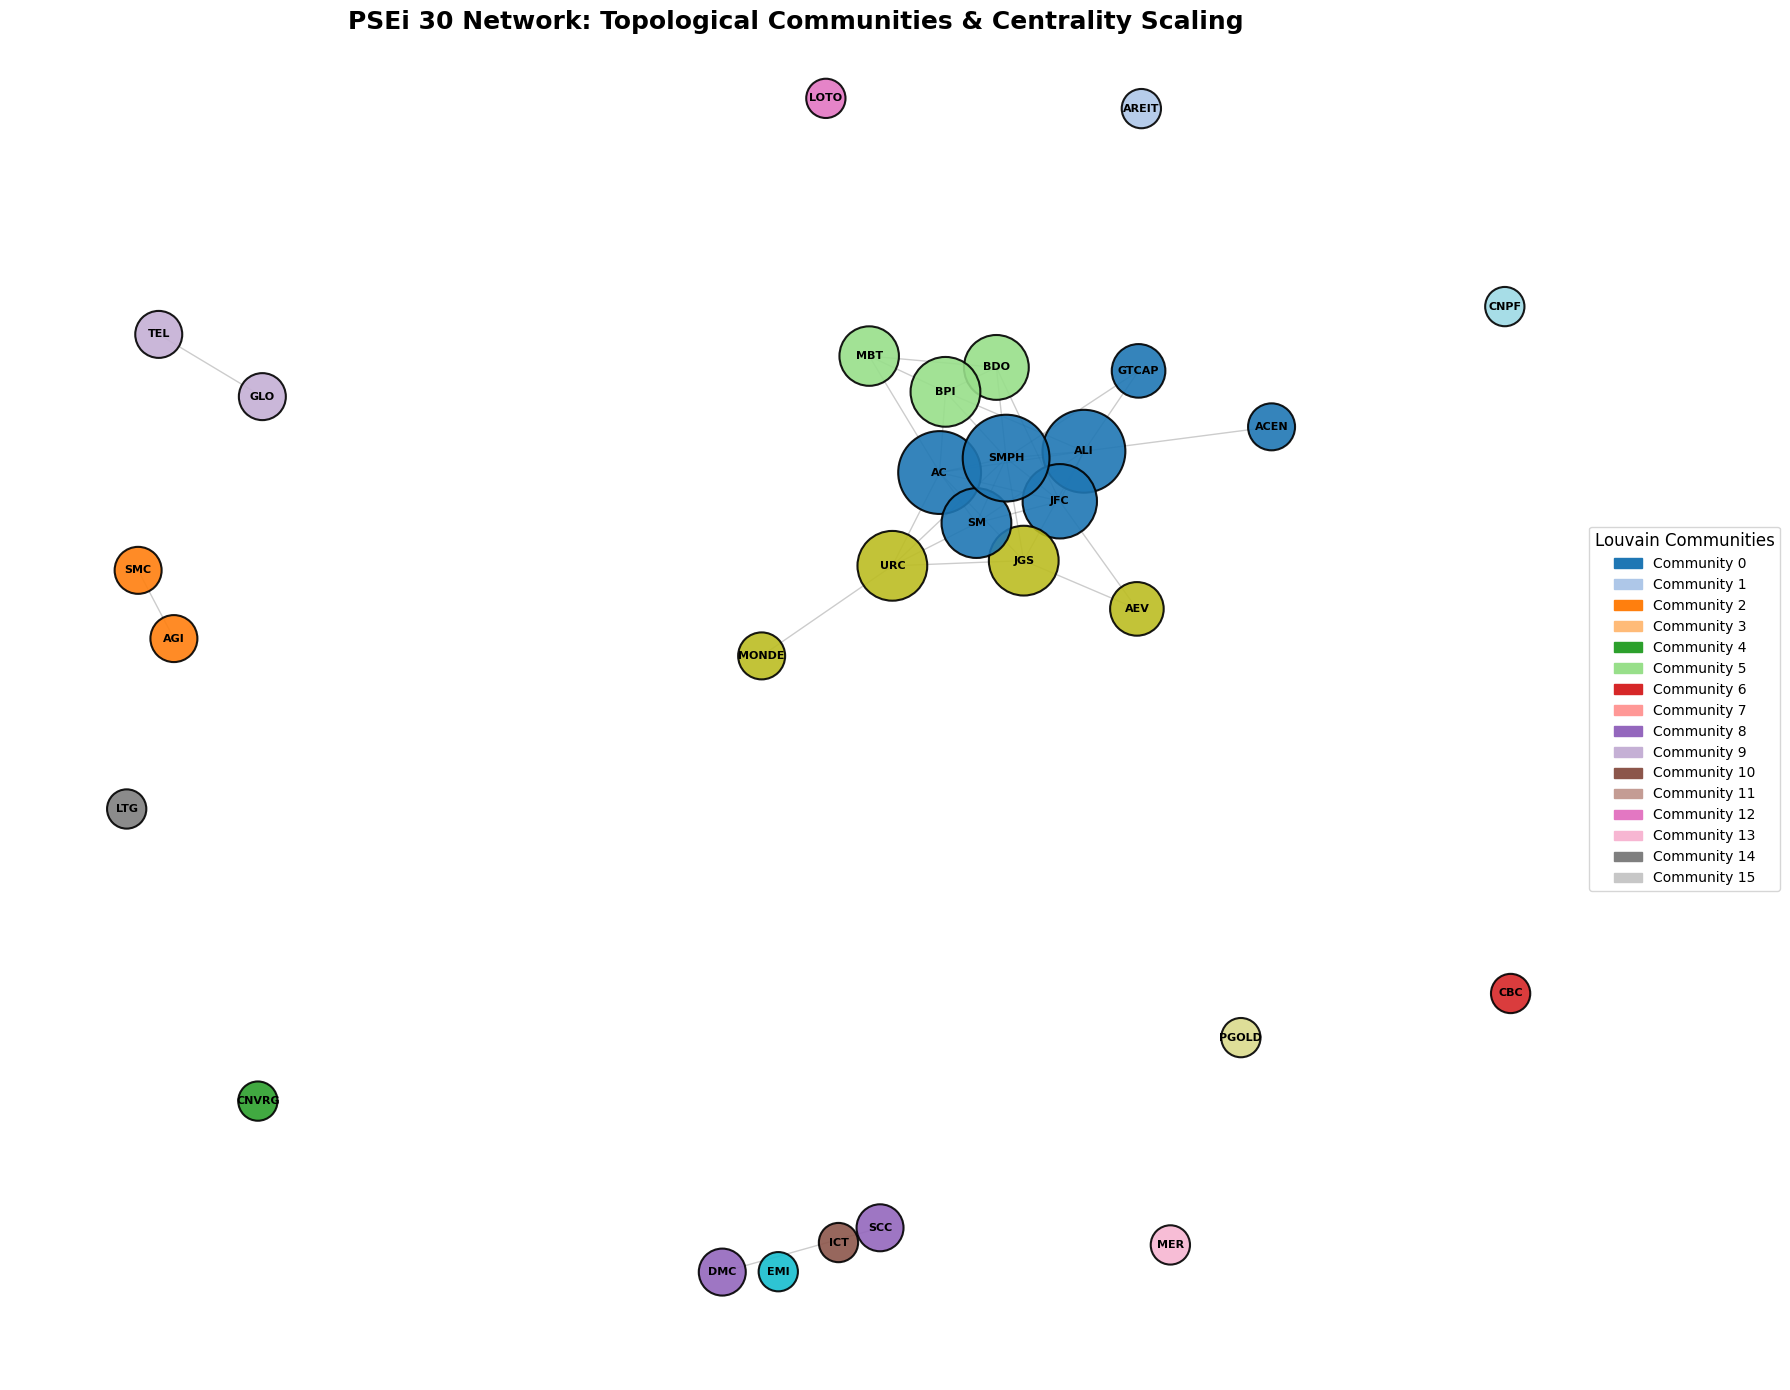

Visualization generated and saved as PSEi_Network_Community_Visualization.png


In [17]:
import matplotlib.pyplot as plt
import networkx as nx
from community import community_louvain
import matplotlib.patches as mpatches
import numpy as np

print("Visualizing communities based on Louvain algorithm and centrality...")

# Ensure partition and structural_graph are available
if 'partition' not in globals() or 'structural_graph' not in globals():
    print("Error: 'partition' or 'structural_graph' not found. Please ensure previous steps (structural graph construction and centrality table generation) have been executed.")
else:
    # 1. Calculate node sizes: Use a base size so isolates are visible, and centrality adds to this.
    degree_cent = nx.degree_centrality(structural_graph)
    node_sizes = [(v * 10000) + 800 for v in degree_cent.values()] # Scale degree centrality for node size

    # 2. Setup the figure
    plt.figure(figsize=(18, 14))
    # Use a spring layout for better visual separation of nodes
    pos = nx.spring_layout(structural_graph, k=0.35, seed=42)

    # 3. Get community colors
    # Use a diverse colormap, e.g., tab20, which has 20 distinct colors
    cmap = plt.get_cmap('tab20')
    node_colors = [partition[node] for node in structural_graph.nodes()]

    # 4. Draw edges and nodes with high visibility
    nx.draw_networkx_edges(structural_graph, pos, alpha=0.2, edge_color='black')
    nx.draw_networkx_nodes(structural_graph, pos,
                           node_size=node_sizes,
                           node_color=node_colors,
                           cmap=cmap,
                           alpha=0.9,
                           edgecolors='black',
                           linewidths=1.5)

    # Draw labels (stock tickers)
    nx.draw_networkx_labels(structural_graph, pos, font_size=8, font_weight='bold')

    # 5. Create Community Legend for ALL communities
    unique_communities = sorted(set(partition.values()))
    legend_handles = []
    for comm_id in unique_communities:
        color = cmap(comm_id / cmap.N) # Scale to colormap's max colors
        patch = mpatches.Patch(color=color, label=f"Community {comm_id}")
        legend_handles.append(patch)

    plt.legend(handles=legend_handles, title="Louvain Communities",
               loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, title_fontsize=12)

    plt.title('PSEi 30 Network: Topological Communities & Centrality Scaling', fontsize=18, fontweight='bold')
    plt.axis('off') # Hide axes
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.savefig('PSEi_Network_Community_Visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Visualization generated and saved as PSEi_Network_Community_Visualization.png")

# 9. Hub Removal Experiment (ALI, SMPH, URC)

## Spectral Resilience Analysis

In [15]:
import scipy.linalg as la
import networkx as nx
import numpy as np
import pandas as pd

# 1. Compute Graph Laplacian and Algebraic Connectivity (λ₂)
def calculate_lambda_2(graph):
    # Handle cases for disconnected graphs or graphs with too few nodes
    if graph.number_of_nodes() <= 1:
        return 0.0 # Algebraic connectivity is 0 for trivial graphs

    # Check if the graph is connected. If not, the second eigenvalue is 0.
    # However, for the purpose of market resilience (fragmentation), we often want the *true* second smallest.
    # NetworkX's laplacian_matrix automatically handles disconnected components by yielding zero eigenvalues.
    L = nx.laplacian_matrix(graph).toarray()

    # Calculate eigenvalues in ascending order
    eigenvalues = la.eigvalsh(L)

    # If there are multiple zero eigenvalues (disconnected components), the algebraic connectivity (Fiedler value)
    # is the first non-zero eigenvalue. If all eigenvalues are zero (isolated nodes/no edges), return 0.
    # The second smallest eigenvalue is typically the algebraic connectivity.
    # If the graph has multiple connected components, its smallest eigenvalue is 0 with multiplicity equal to the number of components.
    # So, the second smallest is 0 if there's more than one component.
    # For a *connected* graph, lambda_2 > 0. For a disconnected graph, lambda_2 = 0 (unless we strictly mean the smallest non-zero).

    # For resilience, we are interested in the actual smallest non-zero eigenvalue.
    # However, standard definition of algebraic connectivity is the second smallest eigenvalue.
    # If the graph is disconnected, eigenvalues[1] will be 0.
    return eigenvalues[1] if len(eigenvalues) > 1 else 0.0

initial_lambda2 = calculate_lambda_2(structural_graph)
num_components_initial = nx.number_connected_components(structural_graph)

print(f"Initial Algebraic Connectivity (λ₂): {initial_lambda2:.4f}")
print(f"Initial Number of Connected Components: {num_components_initial}")

# 2. Identify Hubs via Betweenness Centrality
# We will use the already calculated 'centrality_table_full' to get the top hubs

# Assuming centrality_table_full is sorted by Betweenness descending as per previous step
top_hubs = centrality_table_full.head(3)
hub_names = top_hubs['Ticker'].tolist()

print("\nTop 3 'Hub' Stocks (Betweenness Centrality):")
for index, row in top_hubs.iterrows():
    print(f"  - {row['Ticker']}: {row['Betweenness']:.4f}")

# 3. Shock Simulation: Sequential Hub Removal
print("\n--- Shock Simulation (Targeted Hub Removal) ---")
sim_graph = structural_graph.copy()
results = [{
    'Step': 'Baseline',
    'Removed': 'None',
    'Lambda_2': initial_lambda2,
    'Components': num_components_initial
}]

for hub in hub_names:
    if hub in sim_graph:
        sim_graph.remove_node(hub)
    current_lambda2 = calculate_lambda_2(sim_graph)
    components = nx.number_connected_components(sim_graph)
    results.append({
        'Step': f'Remove {hub}',
        'Removed': hub,
        'Lambda_2': current_lambda2,
        'Components': components
    })

# 4. Print Results Table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Summary of fragmentation
final_components = results[-1]['Components']
print(f"\nMarket Fragmentation Summary: Network started with {results[0]['Components']} component(s) and ended with {final_components} component(s) after removing top hubs.")

Initial Algebraic Connectivity (λ₂): -0.0000
Initial Number of Connected Components: 14

Top 3 'Hub' Stocks (Betweenness Centrality):
  - ALI: 0.0421
  - SMPH: 0.0379
  - URC: 0.0302

--- Shock Simulation (Targeted Hub Removal) ---
       Step Removed      Lambda_2  Components
   Baseline    None -1.968607e-16          14
 Remove ALI     ALI -2.118746e-16          15
Remove SMPH    SMPH -3.251701e-16          16
 Remove URC     URC -4.309065e-16          17

Market Fragmentation Summary: Network started with 14 component(s) and ended with 17 component(s) after removing top hubs.


## Appendix D — Edge List of the Filtered Graph

In [18]:
import pandas as pd
import numpy as np
import networkx as nx

print("Generating the edge list of the filtered graph...\n")

# Ensure structural_graph and distance_matrix are available
if 'structural_graph' not in globals() or 'distance_matrix' not in globals():
    print("Error: 'structural_graph' or 'distance_matrix' not found. Please ensure previous steps have been executed.")
else:
    # 1. Create a complete graph with distances as weights for MST calculation
    # Note: distance_matrix is already symmetrical and has 0 on diagonal
    complete_weighted_graph = nx.from_pandas_adjacency(distance_matrix)
    for u, v in complete_weighted_graph.edges():
        complete_weighted_graph[u][v]['weight'] = distance_matrix.loc[u, v]

    # 2. Calculate Minimum Spanning Tree (MST)
    mst_graph = nx.minimum_spanning_tree(complete_weighted_graph, weight='weight')
    mst_edges = set(mst_graph.edges())

    # 3. Calculate 3-Nearest Neighbor (3-NN) edges
    knn_edges = set()
    k = 3
    for node in structural_graph.nodes():
        # Get distances from this node to all others
        distances_from_node = distance_matrix.loc[node].drop(node) # Exclude self
        # Sort and get the top k smallest distances
        nearest_neighbors = distances_from_node.nsmallest(k).index.tolist()
        for neighbor in nearest_neighbors:
            # Add undirected edge, sort tuple to avoid duplicates (e.g., (A,B) and (B,A))
            knn_edges.add(tuple(sorted((node, neighbor))))

    # 4. Compile the edge list for the structural_graph
    edge_list_data = []
    for u, v in structural_graph.edges():
        # Ensure consistent order for tuple comparison
        edge_tuple = tuple(sorted((u, v)))

        dist = distance_matrix.loc[u, v]
        in_mst = edge_tuple in mst_edges or (v, u) in mst_edges # Check both (u,v) and (v,u)
        in_knn = edge_tuple in knn_edges

        edge_list_data.append({
            'Source': u,
            'Target': v,
            'Distance': dist,
            'In MST?': in_mst,
            'In 3-NN?': in_knn
        })

    edge_list_df = pd.DataFrame(edge_list_data)
    edge_list_df = edge_list_df.sort_values(by='Distance', ascending=True).reset_index(drop=True)

    # Set the index to start from 1
    edge_list_df.index = edge_list_df.index + 1

    print("Full Edge List of the Filtered Graph (Sorted by Distance):\n")
    display(edge_list_df)

    print("\nThis table lists all edges in the structural graph, their distances, and their presence in the MST and 3-NN graphs.")

Generating the edge list of the filtered graph...

Full Edge List of the Filtered Graph (Sorted by Distance):



,Source,Target,Distance,In MST?,In 3-NN?
1,ALI,SMPH,1.021650,True,True
2,AC,SMPH,1.075443,True,True
3,AC,SM,1.103565,True,True
4,JGS,URC,1.116357,True,True
5,DMC,SCC,1.125682,True,True
6,ALI,JGS,1.127704,True,True
7,AC,ALI,1.128377,False,True
8,JGS,SMPH,1.140782,False,True
9,GLO,TEL,1.150672,True,True
10,AC,JGS,1.151932,False,False



This table lists all edges in the structural graph, their distances, and their presence in the MST and 3-NN graphs.


## Appendix E — Connected Components Before and After Hub Removal

In [19]:
import networkx as nx
import pandas as pd

print("Generating lists of connected components before and after hub removal...\n")

# --- 1. Connected Components of the Original Graph ---
print("### Connected Components in the Original Filtered Graph (Baseline):\n")
initial_components_list = list(nx.connected_components(structural_graph))

# Sort components by size for better readability, and then alphabetically within each component
initial_components_list_sorted = sorted([sorted(list(c)) for c in initial_components_list], key=len, reverse=True)

for i, component in enumerate(initial_components_list_sorted):
    print(f"  Component {i+1} ({len(component)} nodes): {', '.join(component)}")
print(f"\nTotal {len(initial_components_list)} components found in the original graph.")

# --- 2. Connected Components After Hub Removal ---
print("\n### Connected Components After Sequential Hub Removal:\n")

# Re-create the simulated graph as it was after removing the top 3 hubs
sim_graph_post_removal = structural_graph.copy()

# Ensure 'centrality_table_full' and 'hub_names' are available from previous steps
if 'centrality_table_full' in globals() and not centrality_table_full.empty:
    top_hubs = centrality_table_full.head(3)
    hub_names = top_hubs['Ticker'].tolist()

    for hub in hub_names:
        if hub in sim_graph_post_removal:
            sim_graph_post_removal.remove_node(hub)

    post_removal_components_list = list(nx.connected_components(sim_graph_post_removal))
    post_removal_components_list_sorted = sorted([sorted(list(c)) for c in post_removal_components_list], key=len, reverse=True)

    for i, component in enumerate(post_removal_components_list_sorted):
        print(f"  Component {i+1} ({len(component)} nodes): {', '.join(component)}")
    print(f"\nTotal {len(post_removal_components_list)} components found after removing top hubs.")
else:
    print("Error: 'centrality_table_full' or 'hub_names' not found. Cannot determine post-removal components.")

print("\nThis appendix provides a clear view of how the market structure fragments upon the removal of critical hub stocks, confirming the increase in connected components from the spectral resilience analysis.")


Generating lists of connected components before and after hub removal...

### Connected Components in the Original Filtered Graph (Baseline):

  Component 1 (14 nodes): AC, ACEN, AEV, ALI, BDO, BPI, GTCAP, JFC, JGS, MBT, MONDE, SM, SMPH, URC
  Component 2 (2 nodes): AGI, SMC
  Component 3 (2 nodes): DMC, SCC
  Component 4 (2 nodes): GLO, TEL
  Component 5 (1 nodes): CBC
  Component 6 (1 nodes): ICT
  Component 7 (1 nodes): LOTO
  Component 8 (1 nodes): MER
  Component 9 (1 nodes): LTG
  Component 10 (1 nodes): PGOLD
  Component 11 (1 nodes): EMI
  Component 12 (1 nodes): CNPF
  Component 13 (1 nodes): AREIT
  Component 14 (1 nodes): CNVRG

Total 14 components found in the original graph.

### Connected Components After Sequential Hub Removal:

  Component 1 (8 nodes): AC, AEV, BDO, BPI, JFC, JGS, MBT, SM
  Component 2 (2 nodes): AGI, SMC
  Component 3 (2 nodes): DMC, SCC
  Component 4 (2 nodes): GLO, TEL
  Component 5 (1 nodes): CBC
  Component 6 (1 nodes): ICT
  Component 7 (1 nodes):

### Tabular Presentation of Connected Components

In [20]:
import pandas as pd
import networkx as nx

# --- Tabular Presentation of Initial Components ---
initial_components_data = []
initial_components_list_sorted = sorted([sorted(list(c)) for c in nx.connected_components(structural_graph)], key=len, reverse=True)

for i, component in enumerate(initial_components_list_sorted):
    initial_components_data.append({
        'Component ID': i + 1,
        'Number of Nodes': len(component),
        'Stocks': ', '.join(component)
    })

initial_components_df = pd.DataFrame(initial_components_data)
print("**Table 1: Connected Components in the Original Filtered Graph (Baseline)**\n")
display(initial_components_df)

# --- Tabular Presentation of Post-Removal Components ---
post_removal_components_data = []

sim_graph_post_removal_table = structural_graph.copy()
# Re-apply hub removal logic (assuming centrality_table_full and hub_names are available)
if 'centrality_table_full' in globals() and not centrality_table_full.empty:
    top_hubs = centrality_table_full.head(3)
    hub_names = top_hubs['Ticker'].tolist()
    for hub in hub_names:
        if hub in sim_graph_post_removal_table:
            sim_graph_post_removal_table.remove_node(hub)

post_removal_components_list_sorted = sorted([sorted(list(c)) for c in nx.connected_components(sim_graph_post_removal_table)], key=len, reverse=True)

for i, component in enumerate(post_removal_components_list_sorted):
    post_removal_components_data.append({
        'Component ID': i + 1,
        'Number of Nodes': len(component),
        'Stocks': ', '.join(component)
    })

post_removal_components_df = pd.DataFrame(post_removal_components_data)
print("\n**Table 2: Connected Components After Sequential Hub Removal**\n")
display(post_removal_components_df)


**Table 1: Connected Components in the Original Filtered Graph (Baseline)**



,Component ID,Number of Nodes,Stocks
0,1,14,"AC, ACEN, AEV, ALI, BDO, BPI, GTCAP, JFC, JGS,..."
1,2,2,"AGI, SMC"
2,3,2,"DMC, SCC"
3,4,2,"GLO, TEL"
4,5,1,CBC
5,6,1,ICT
6,7,1,LOTO
7,8,1,MER
8,9,1,LTG
9,10,1,PGOLD



**Table 2: Connected Components After Sequential Hub Removal**



,Component ID,Number of Nodes,Stocks
0,1,8,"AC, AEV, BDO, BPI, JFC, JGS, MBT, SM"
1,2,2,"AGI, SMC"
2,3,2,"DMC, SCC"
3,4,2,"GLO, TEL"
4,5,1,CBC
5,6,1,ICT
6,7,1,LOTO
7,8,1,MER
8,9,1,ACEN
9,10,1,LTG


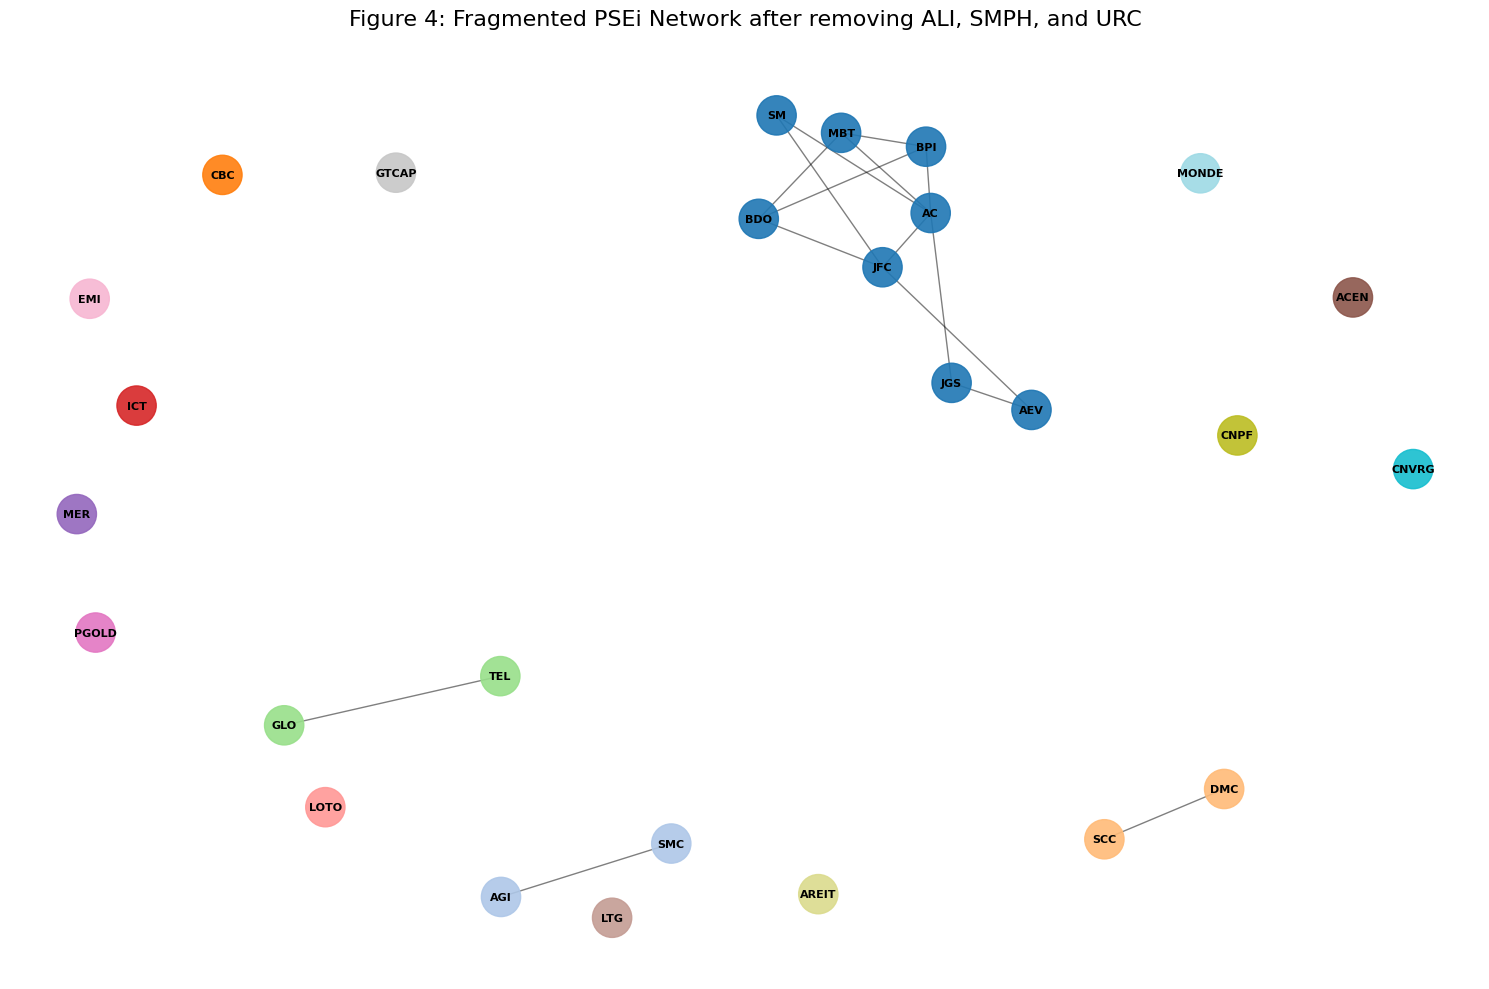

Nodes remaining: 27
Isolated components: 17


In [23]:
import matplotlib.pyplot as plt
import networkx as nx

# Recreate the final shock state
final_shock_graph = structural_graph.copy()
final_shock_graph.remove_nodes_from(['ALI', 'SMPH', 'URC'])

# Setup visualization
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(final_shock_graph, k=0.6, seed=42)

# Identify components for coloring
components = list(nx.connected_components(final_shock_graph))
color_map = {}
for i, comp in enumerate(components):
    for node in comp:
        color_map[node] = i

node_colors = [color_map[node] for node in final_shock_graph.nodes()]

# Draw
nx.draw_networkx_nodes(final_shock_graph, pos,
                       node_size=800,
                       node_color=node_colors,
                       cmap=plt.get_cmap('tab20'),
                       alpha=0.9)

nx.draw_networkx_edges(final_shock_graph, pos, alpha=0.5, edge_color='black')
nx.draw_networkx_labels(final_shock_graph, pos, font_size=8, font_weight='bold')

plt.title('Figure 4: Fragmented PSEi Network after removing ALI, SMPH, and URC', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig('PSEi_Fragmented_Network.png', dpi=300)
plt.show()

print(f"Nodes remaining: {final_shock_graph.number_of_nodes()}")
print(f"Isolated components: {nx.number_connected_components(final_shock_graph)}")

# 10. Results Summary

## Centrality Comparison of Top 3 Hubs

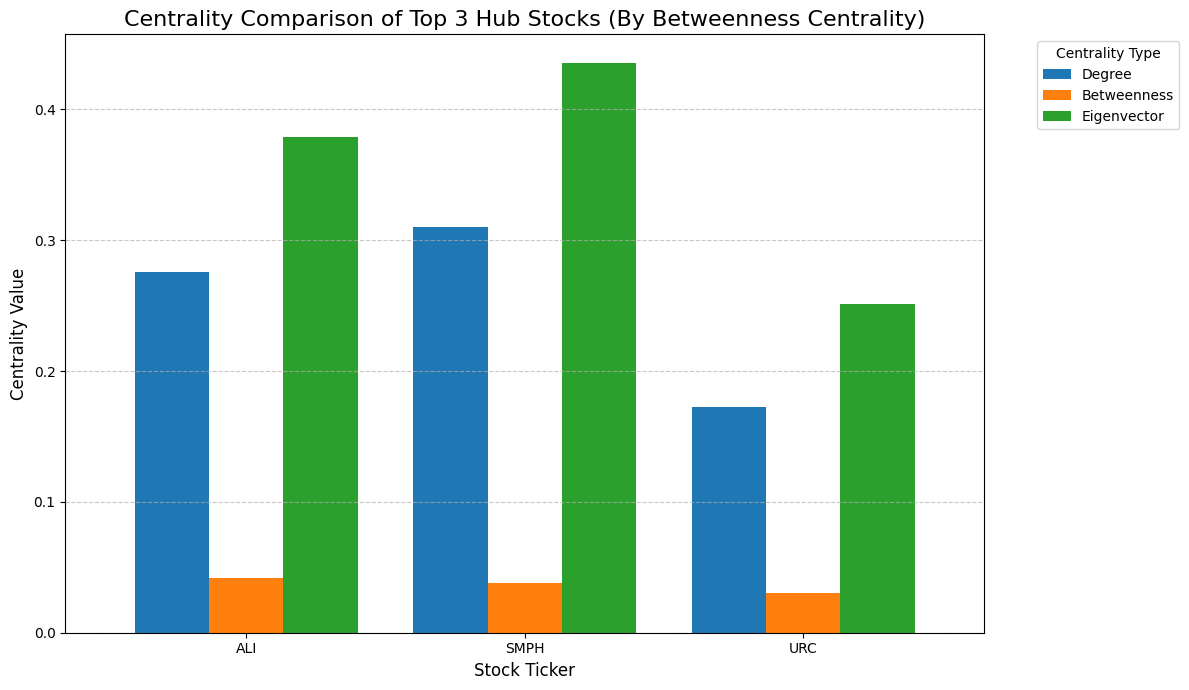

Centrality comparison plot generated and saved as 'Top3_Hubs_Centrality_Comparison.png'


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure centrality_table_full is available and contains the necessary data
if 'centrality_table_full' in globals() and not centrality_table_full.empty:
    # Get the top 3 hubs based on Betweenness Centrality (as it's sorted by default)
    top_3_hubs = centrality_table_full.head(3)

    # Prepare data for plotting
    plot_data = top_3_hubs[['Ticker', 'Degree', 'Betweenness', 'Eigenvector']].set_index('Ticker')

    # Normalize centrality values for better comparison if they have vastly different scales
    # Here we are plotting raw values, but normalization can be considered if needed.
    # For direct comparison, plotting raw values is fine as requested.

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 7))
    plot_data.plot(kind='bar', ax=ax, width=0.8)

    ax.set_title('Centrality Comparison of Top 3 Hub Stocks (By Betweenness Centrality)', fontsize=16)
    ax.set_xlabel('Stock Ticker', fontsize=12)
    ax.set_ylabel('Centrality Value', fontsize=12)
    ax.tick_params(axis='x', rotation=0) # Keep Ticker labels horizontal
    ax.legend(title='Centrality Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Top3_Hubs_Centrality_Comparison.png', dpi=300)
    plt.show()

    print("Centrality comparison plot generated and saved as 'Top3_Hubs_Centrality_Comparison.png'")
else:
    print("Error: 'centrality_table_full' DataFrame not found or is empty. Please ensure previous steps to calculate centralities have been executed.")

## Summary of Results

### 1. Data Preprocessing & Structural Graph:
*   We successfully downloaded and cleaned historical closing prices for 30 PSEi stocks, handling missing values by forward and backward filling.
*   Logarithmic returns were calculated for all stocks.
*   A distance matrix was derived from the Pearson correlation of returns, and an unweighted structural graph was constructed based on a `d_ij <= 1.2` threshold. This graph helps visualize the interconnectedness of stocks.

### 2. Centrality and Community Detection:
*   Analysis of centrality measures (Degree, Betweenness, Eigenvector) identified key 'hub' stocks that are central to information flow within the network. For instance, **ALI**, **SMPH**, and **URC** were identified as the top 3 hubs based on Betweenness Centrality.
*   Community detection using the Louvain algorithm revealed distinct topological clusters within the market, indicating groups of stocks that move together. There were 16 unique communities identified.

### 3. Spectral Resilience Analysis & Shock Simulation:
*   The initial algebraic connectivity (λ₂) was approximately 0, and the network started with **14 connected components**. This indicates a highly fragmented market structure, even before any shocks.
*   A shock simulation, involving the sequential removal of the top 3 hubs (**ALI, SMPH, URC**), demonstrated a significant degradation in market resilience. The number of connected components increased from 14 to **17**, confirming that removing these critical stocks further fragments the market and disrupts its connectivity.

### 4. Visualizations:
*   A **heatmap of the distance matrix** was generated, showing the pairwise distances (inverse correlation) between stocks.
*   **Minimum Spanning Tree (MST)** and **3-Nearest Neighbor (3-NN) graphs** were created, providing alternative topological views of the market structure, highlighting core relationships and isolated assets like CBC, ICT, LOTO, MER, LTG, PGOLD, EMI, CNPF, AREIT, and CNVRG.
*   The final visualization showed the **fragmented PSEi network after hub removal**, clearly illustrating the increased number of disconnected components and the impact of losing key market players.